In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler

In [213]:
data=pd.read_csv('train_FD004.txt' , header=None , sep=" ")
data

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,5.70,137.36,2211.86,8311.32,1.01,41.69,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670,NaN,NaN
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,13.61,332.10,2323.66,8713.60,1.07,43.94,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552,NaN,NaN
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,5.69,138.18,2211.92,8306.69,1.01,41.66,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213,NaN,NaN
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,5.70,137.98,2211.88,8312.35,1.02,41.68,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176,NaN,NaN
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,9.00,174.82,1915.22,7994.94,0.93,36.48,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61244,249,251,9.9998,0.2500,100.0,489.05,605.33,1516.36,1315.28,10.52,15.46,404.59,2319.66,8840.16,1.27,46.08,380.16,2388.73,8185.69,8.4541,0.03,372,2319,100.00,29.11,17.5234,NaN,NaN
61245,249,252,0.0028,0.0015,100.0,518.67,643.42,1598.92,1426.77,14.62,21.57,567.59,2388.47,9117.12,1.31,48.04,535.02,2388.46,8185.47,8.2221,0.03,396,2388,100.00,39.38,23.7151,NaN,NaN
61246,249,253,0.0029,0.0000,100.0,518.67,643.68,1607.72,1430.56,14.62,21.57,569.04,2388.51,9126.53,1.31,48.24,535.41,2388.48,8193.94,8.2525,0.03,395,2388,100.00,39.78,23.8270,NaN,NaN
61247,249,254,35.0046,0.8400,100.0,449.44,555.77,1381.29,1148.18,5.48,7.96,199.93,2223.78,8403.64,1.05,42.53,187.92,2388.83,8125.64,9.0515,0.02,337,2223,100.00,15.26,9.0774,NaN,NaN


In [214]:
data.columns=["unit_number", "time_cycles", "op_setting_1", "op_setting_2", "op_setting_3"] + [f"sensor_{i}" for i in range(1, 24)]

In [215]:
data.describe()

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23
count,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,0.0,0.0
mean,124.325181,134.311417,23.999823,0.571347,94.031576,472.882435,579.420056,1417.896600,1201.915359,8.031626,11.589457,283.328633,2228.686034,8524.673301,1.096445,42.874529,266.735665,2334.427590,8067.811812,9.285604,0.023252,347.760029,2228.613283,97.751396,20.864333,12.518995,NaN,NaN
std,71.995350,89.783389,14.780722,0.310703,14.251954,26.436832,37.342647,106.167598,119.327591,3.622872,5.444017,146.880210,145.348243,336.927547,0.127681,3.243492,138.479109,128.197859,85.670543,0.750374,0.004685,27.808283,145.472491,5.369424,9.936396,5.962697,NaN,NaN
min,1.000000,1.000000,0.000000,0.000000,60.000000,445.000000,535.480000,1242.670000,1024.420000,3.910000,5.670000,136.170000,1914.720000,7984.510000,0.930000,36.040000,128.310000,2027.570000,7845.780000,8.175700,0.020000,302.000000,1915.000000,84.930000,10.160000,6.084300,NaN,NaN
25%,60.000000,62.000000,10.004600,0.250700,100.000000,445.000000,549.330000,1350.550000,1119.490000,3.910000,5.720000,142.920000,2211.950000,8320.590000,1.020000,41.760000,134.520000,2387.910000,8062.630000,8.648000,0.020000,330.000000,2212.000000,100.000000,10.940000,6.566100,NaN,NaN
50%,126.000000,123.000000,25.001400,0.700000,100.000000,462.540000,555.740000,1367.680000,1136.920000,7.050000,9.030000,194.960000,2223.070000,8362.760000,1.030000,42.330000,183.450000,2388.060000,8083.810000,9.255600,0.020000,334.000000,2223.000000,100.000000,14.930000,8.960100,NaN,NaN
75%,185.000000,191.000000,41.998100,0.840000,100.000000,491.190000,607.070000,1497.420000,1302.620000,10.520000,15.480000,394.280000,2323.930000,8777.250000,1.260000,45.220000,371.400000,2388.170000,8128.350000,9.365800,0.030000,368.000000,2324.000000,100.000000,28.560000,17.135500,NaN,NaN
max,249.000000,543.000000,42.008000,0.842000,100.000000,518.670000,644.420000,1613.000000,1440.770000,14.620000,21.610000,570.810000,2388.640000,9196.810000,1.320000,48.360000,537.490000,2390.490000,8261.650000,11.066300,0.030000,399.000000,2388.000000,100.000000,39.890000,23.885200,NaN,NaN


In [216]:
data.isnull().sum()

,0
unit_number,0
time_cycles,0
op_setting_1,0
op_setting_2,0
op_setting_3,0
sensor_1,0
sensor_2,0
sensor_3,0
sensor_4,0
sensor_5,0


In [217]:
data.drop(['sensor_22','sensor_23'] , axis=1 , inplace=True)
data

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,5.70,137.36,2211.86,8311.32,1.01,41.69,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,13.61,332.10,2323.66,8713.60,1.07,43.94,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,5.69,138.18,2211.92,8306.69,1.01,41.66,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,5.70,137.98,2211.88,8312.35,1.02,41.68,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,9.00,174.82,1915.22,7994.94,0.93,36.48,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61244,249,251,9.9998,0.2500,100.0,489.05,605.33,1516.36,1315.28,10.52,15.46,404.59,2319.66,8840.16,1.27,46.08,380.16,2388.73,8185.69,8.4541,0.03,372,2319,100.00,29.11,17.5234
61245,249,252,0.0028,0.0015,100.0,518.67,643.42,1598.92,1426.77,14.62,21.57,567.59,2388.47,9117.12,1.31,48.04,535.02,2388.46,8185.47,8.2221,0.03,396,2388,100.00,39.38,23.7151
61246,249,253,0.0029,0.0000,100.0,518.67,643.68,1607.72,1430.56,14.62,21.57,569.04,2388.51,9126.53,1.31,48.24,535.41,2388.48,8193.94,8.2525,0.03,395,2388,100.00,39.78,23.8270
61247,249,254,35.0046,0.8400,100.0,449.44,555.77,1381.29,1148.18,5.48,7.96,199.93,2223.78,8403.64,1.05,42.53,187.92,2388.83,8125.64,9.0515,0.02,337,2223,100.00,15.26,9.0774


In [218]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61249 entries, 0 to 61248
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   unit_number   61249 non-null  int64  
 1   time_cycles   61249 non-null  int64  
 2   op_setting_1  61249 non-null  float64
 3   op_setting_2  61249 non-null  float64
 4   op_setting_3  61249 non-null  float64
 5   sensor_1      61249 non-null  float64
 6   sensor_2      61249 non-null  float64
 7   sensor_3      61249 non-null  float64
 8   sensor_4      61249 non-null  float64
 9   sensor_5      61249 non-null  float64
 10  sensor_6      61249 non-null  float64
 11  sensor_7      61249 non-null  float64
 12  sensor_8      61249 non-null  float64
 13  sensor_9      61249 non-null  float64
 14  sensor_10     61249 non-null  float64
 15  sensor_11     61249 non-null  float64
 16  sensor_12     61249 non-null  float64
 17  sensor_13     61249 non-null  float64
 18  sensor_14     61249 non-nu

In [219]:
max_cycles=data.groupby('unit_number')['time_cycles'].transform('max')
data['RUL']=max_cycles - data['time_cycles']
data

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,5.70,137.36,2211.86,8311.32,1.01,41.69,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670,320
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,13.61,332.10,2323.66,8713.60,1.07,43.94,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552,319
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,5.69,138.18,2211.92,8306.69,1.01,41.66,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213,318
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,5.70,137.98,2211.88,8312.35,1.02,41.68,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176,317
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,9.00,174.82,1915.22,7994.94,0.93,36.48,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754,316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61244,249,251,9.9998,0.2500,100.0,489.05,605.33,1516.36,1315.28,10.52,15.46,404.59,2319.66,8840.16,1.27,46.08,380.16,2388.73,8185.69,8.4541,0.03,372,2319,100.00,29.11,17.5234,4
61245,249,252,0.0028,0.0015,100.0,518.67,643.42,1598.92,1426.77,14.62,21.57,567.59,2388.47,9117.12,1.31,48.04,535.02,2388.46,8185.47,8.2221,0.03,396,2388,100.00,39.38,23.7151,3
61246,249,253,0.0029,0.0000,100.0,518.67,643.68,1607.72,1430.56,14.62,21.57,569.04,2388.51,9126.53,1.31,48.24,535.41,2388.48,8193.94,8.2525,0.03,395,2388,100.00,39.78,23.8270,2
61247,249,254,35.0046,0.8400,100.0,449.44,555.77,1381.29,1148.18,5.48,7.96,199.93,2223.78,8403.64,1.05,42.53,187.92,2388.83,8125.64,9.0515,0.02,337,2223,100.00,15.26,9.0774,1


In [220]:
test=pd.read_csv('test_FD004.txt' , header=None , sep=" ")
test.columns=["unit_number", "time_cycles", "op_setting_1", "op_setting_2", "op_setting_3"] + [f"sensor_{i}" for i in range(1, 24)]
test.drop(['sensor_22','sensor_23'] , axis=1 , inplace=True)
test

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,20.0072,0.7000,100.0,491.19,606.67,1481.04,1227.81,9.35,13.60,332.52,2323.67,8704.98,1.07,43.83,313.03,2387.78,8048.98,9.2229,0.02,362,2324,100.00,24.31,14.7007
1,1,2,24.9984,0.6200,60.0,462.54,536.22,1256.17,1031.48,7.05,9.00,174.46,1915.21,7999.94,0.93,36.11,163.61,2028.09,7863.46,10.8632,0.02,306,1915,84.93,14.36,8.5748
2,1,3,42.0000,0.8420,100.0,445.00,549.23,1340.13,1105.88,3.91,5.69,137.34,2211.93,8305.38,1.01,41.52,129.98,2387.95,8071.13,9.3960,0.02,328,2212,100.00,10.39,6.4365
3,1,4,42.0035,0.8402,100.0,445.00,549.19,1339.70,1107.26,3.91,5.69,137.23,2211.89,8301.00,1.01,41.73,129.48,2387.90,8078.89,9.3594,0.02,328,2212,100.00,10.56,6.2367
4,1,5,35.0079,0.8400,100.0,449.44,555.10,1353.04,1117.80,5.48,7.97,192.94,2222.71,8331.05,1.02,41.32,181.82,2387.87,8057.83,9.3030,0.02,333,2223,100.00,14.85,8.9326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41209,248,277,41.9991,0.8401,100.0,445.00,550.30,1364.40,1129.17,3.91,5.72,138.34,2212.35,8351.73,1.02,42.30,130.87,2388.50,8112.61,9.4427,0.02,331,2212,100.00,10.53,6.2620
41210,248,278,20.0026,0.7005,100.0,491.19,608.00,1494.75,1260.88,9.35,13.66,334.75,2324.23,8758.69,1.07,44.53,314.51,2388.33,8086.83,9.2772,0.02,366,2324,100.00,24.33,14.6486
41211,248,279,34.9988,0.8413,100.0,449.44,555.92,1370.65,1130.97,5.48,8.00,194.92,2223.57,8370.49,1.02,42.33,182.76,2388.64,8100.84,9.3982,0.02,336,2223,100.00,14.69,8.8389
41212,248,280,20.0027,0.7000,100.0,491.19,608.19,1489.11,1256.25,9.35,13.66,333.15,2324.19,8753.04,1.07,44.78,314.17,2388.37,8085.24,9.2727,0.03,366,2324,100.00,24.44,14.6887


In [221]:

ops_cols = ['op_setting_1', 'op_setting_2', 'op_setting_3']

ops_scaler = MinMaxScaler(feature_range=(-1, 1))
data[ops_cols] = ops_scaler.fit_transform(data[ops_cols])
test[ops_cols] = ops_scaler.transform(test[ops_cols])


In [222]:
data

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,0.999852,0.995249,1.0,445.00,549.68,1343.43,1112.93,3.91,5.70,137.36,2211.86,8311.32,1.01,41.69,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670,320
1,1,2,-0.047705,0.663183,1.0,491.19,606.07,1477.61,1237.50,9.35,13.61,332.10,2323.66,8713.60,1.07,43.94,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552,319
2,1,3,0.999800,0.997387,1.0,445.00,548.95,1343.12,1117.05,3.91,5.69,138.18,2211.92,8306.69,1.01,41.66,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213,318
3,1,4,0.999619,0.995249,1.0,445.00,548.70,1341.24,1118.03,3.91,5.70,137.98,2211.88,8312.35,1.02,41.68,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176,317
4,1,5,0.190549,0.474347,-1.0,462.54,536.10,1255.23,1033.59,7.05,9.00,174.82,1915.22,7994.94,0.93,36.48,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754,316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61244,249,251,-0.523910,-0.406176,1.0,489.05,605.33,1516.36,1315.28,10.52,15.46,404.59,2319.66,8840.16,1.27,46.08,380.16,2388.73,8185.69,8.4541,0.03,372,2319,100.00,29.11,17.5234,4
61245,249,252,-0.999867,-0.996437,1.0,518.67,643.42,1598.92,1426.77,14.62,21.57,567.59,2388.47,9117.12,1.31,48.04,535.02,2388.46,8185.47,8.2221,0.03,396,2388,100.00,39.38,23.7151,3
61246,249,253,-0.999862,-1.000000,1.0,518.67,643.68,1607.72,1430.56,14.62,21.57,569.04,2388.51,9126.53,1.31,48.24,535.41,2388.48,8193.94,8.2525,0.03,395,2388,100.00,39.78,23.8270,2
61247,249,254,0.666568,0.995249,1.0,449.44,555.77,1381.29,1148.18,5.48,7.96,199.93,2223.78,8403.64,1.05,42.53,187.92,2388.83,8125.64,9.0515,0.02,337,2223,100.00,15.26,9.0774,1


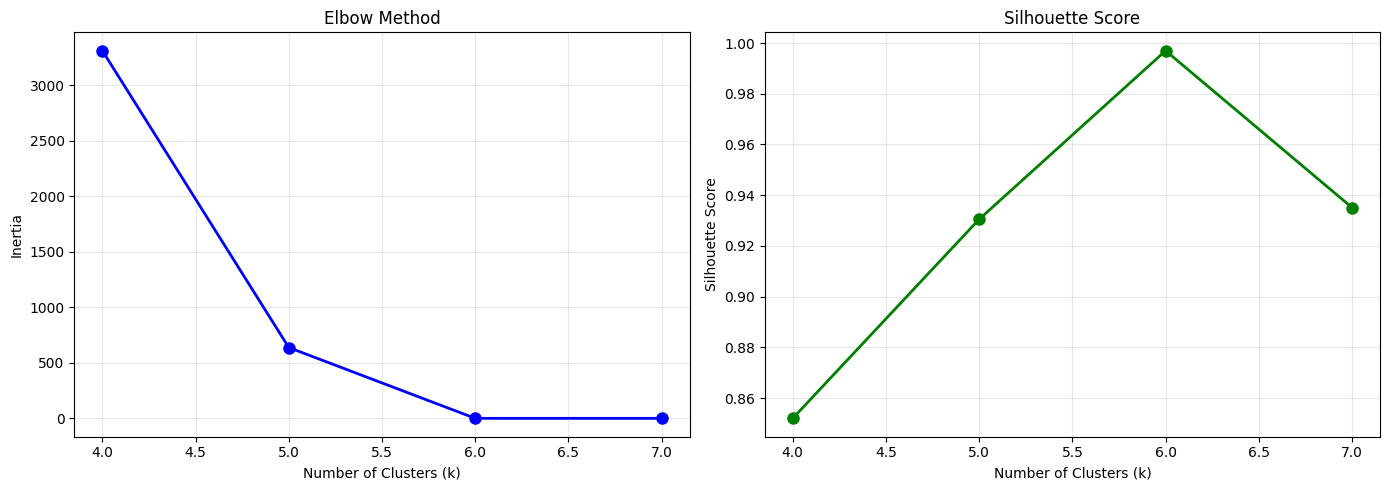

In [159]:

ops_train = data[['op_setting_1', 'op_setting_2', 'op_setting_3']]

inertias = []
silhouette_scores = []
K_range = range(4, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = kmeans.fit_predict(ops_train)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(ops_train, labels))

#plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [223]:
k_optimal = 6

kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=50)
data['regime'] = kmeans_final.fit_predict(ops_train)
test['regime'] = kmeans_final.predict(
    test[['op_setting_1', 'op_setting_2', 'op_setting_3']]
)
data

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL,regime
0,1,1,0.999852,0.995249,1.0,445.00,549.68,1343.43,1112.93,3.91,5.70,137.36,2211.86,8311.32,1.01,41.69,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670,320,0
1,1,2,-0.047705,0.663183,1.0,491.19,606.07,1477.61,1237.50,9.35,13.61,332.10,2323.66,8713.60,1.07,43.94,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552,319,3
2,1,3,0.999800,0.997387,1.0,445.00,548.95,1343.12,1117.05,3.91,5.69,138.18,2211.92,8306.69,1.01,41.66,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213,318,0
3,1,4,0.999619,0.995249,1.0,445.00,548.70,1341.24,1118.03,3.91,5.70,137.98,2211.88,8312.35,1.02,41.68,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176,317,0
4,1,5,0.190549,0.474347,-1.0,462.54,536.10,1255.23,1033.59,7.05,9.00,174.82,1915.22,7994.94,0.93,36.48,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754,316,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61244,249,251,-0.523910,-0.406176,1.0,489.05,605.33,1516.36,1315.28,10.52,15.46,404.59,2319.66,8840.16,1.27,46.08,380.16,2388.73,8185.69,8.4541,0.03,372,2319,100.00,29.11,17.5234,4,1
61245,249,252,-0.999867,-0.996437,1.0,518.67,643.42,1598.92,1426.77,14.62,21.57,567.59,2388.47,9117.12,1.31,48.04,535.02,2388.46,8185.47,8.2221,0.03,396,2388,100.00,39.38,23.7151,3,4
61246,249,253,-0.999862,-1.000000,1.0,518.67,643.68,1607.72,1430.56,14.62,21.57,569.04,2388.51,9126.53,1.31,48.24,535.41,2388.48,8193.94,8.2525,0.03,395,2388,100.00,39.78,23.8270,2,4
61247,249,254,0.666568,0.995249,1.0,449.44,555.77,1381.29,1148.18,5.48,7.96,199.93,2223.78,8403.64,1.05,42.53,187.92,2388.83,8125.64,9.0515,0.02,337,2223,100.00,15.26,9.0774,1,5


In [224]:
# Remove Useless Sensors

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]

sensor_cv = data[sensor_cols].std() / data[sensor_cols].mean().abs()
print(sensor_cv)

useless_sensors = sensor_cv[sensor_cv < 0.001].index.tolist()
print(f"Useless: {useless_sensors}")

data.drop(useless_sensors, axis=1, inplace=True)
test.drop(useless_sensors, axis=1, inplace=True)

sensor_cols = [col for col in sensor_cols if col not in useless_sensors]

sensor_1     0.055906
sensor_2     0.064448
sensor_3     0.074877
sensor_4     0.099281
sensor_5     0.451076
sensor_6     0.469739
sensor_7     0.518409
sensor_8     0.065217
sensor_9     0.039524
sensor_10    0.116450
sensor_11    0.075651
sensor_12    0.519162
sensor_13    0.054916
sensor_14    0.010619
sensor_15    0.080810
sensor_16    0.201471
sensor_17    0.079964
sensor_18    0.065275
sensor_19    0.054929
sensor_20    0.476238
sensor_21    0.476292
dtype: float64
Useless: []


In [225]:
regime_corrs = []

for regime_id in range(k_optimal):
    regime_data = data[data['regime'] == regime_id]
    corr = regime_data[sensor_cols + ['RUL']].corr()['RUL'].drop('RUL')
    regime_corrs.append(corr.abs())

corr_df = pd.DataFrame(regime_corrs)
pd.set_option('display.max_columns', None)
print(corr_df)

     sensor_1  sensor_2  sensor_3  sensor_4  sensor_5  sensor_6  sensor_7  \
RUL       NaN  0.500543  0.599331  0.668716       NaN  0.184983  0.316318   
RUL       NaN  0.594763  0.600974  0.678704       NaN  0.248634  0.272343   
RUL       NaN  0.451263  0.527026  0.589808       NaN  0.204642  0.279255   
RUL       NaN  0.548239  0.591386  0.660975       NaN  0.201423  0.305132   
RUL       NaN  0.585342  0.603595  0.657667       NaN  0.135955  0.254715   
RUL       NaN  0.527073  0.573343  0.652493       NaN  0.141221  0.300263   

     sensor_8  sensor_9  sensor_10  sensor_11  sensor_12  sensor_13  \
RUL  0.280058  0.532590   0.401337   0.698638   0.341806   0.282397   
RUL  0.680927  0.525739   0.378926   0.702216   0.293122   0.680948   
RUL  0.400077  0.522362   0.167790   0.650222   0.305005   0.400384   
RUL  0.638591  0.520083   0.246807   0.690117   0.321076   0.638242   
RUL  0.590894  0.510558   0.361705   0.689286   0.272689   0.591872   
RUL  0.461952  0.525441   0.280067

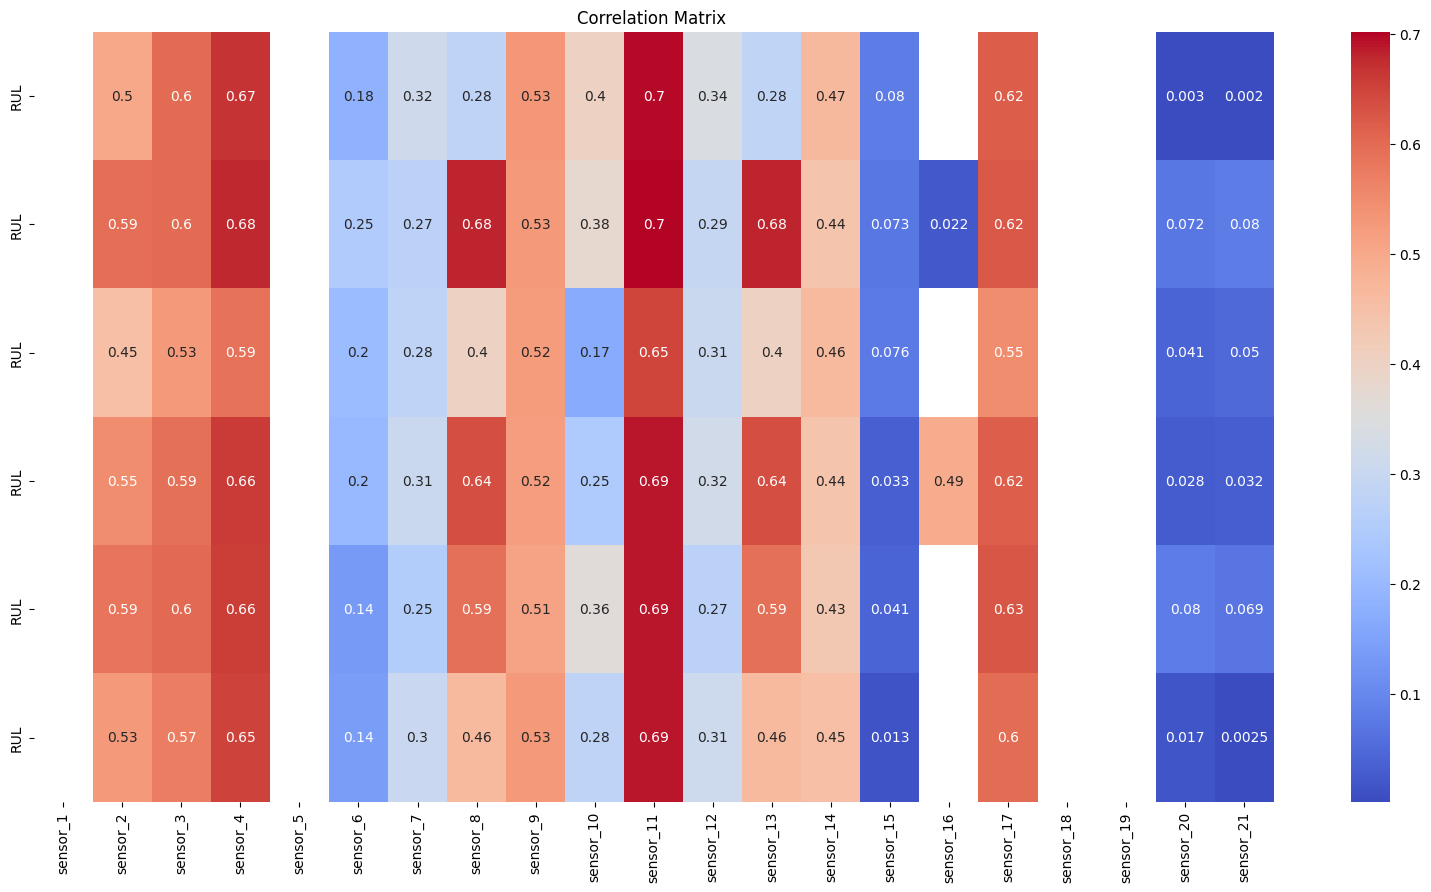

In [226]:
plt.figure(figsize=(20,10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix ')
plt.show()

In [227]:
data.drop(['sensor_1','sensor_5','sensor_18','sensor_19'] ,axis=1, inplace=True )

In [228]:
test.drop(['sensor_1','sensor_5','sensor_18','sensor_19'] ,axis=1, inplace=True )

In [166]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [229]:
features = data.drop(['unit_number', 'time_cycles', 'RUL'], axis=1)
target = data['RUL']

In [230]:
pca = PCA(n_components=2)  # Reduce to 2 dimensions for visualization
X_pca = pca.fit_transform(features)

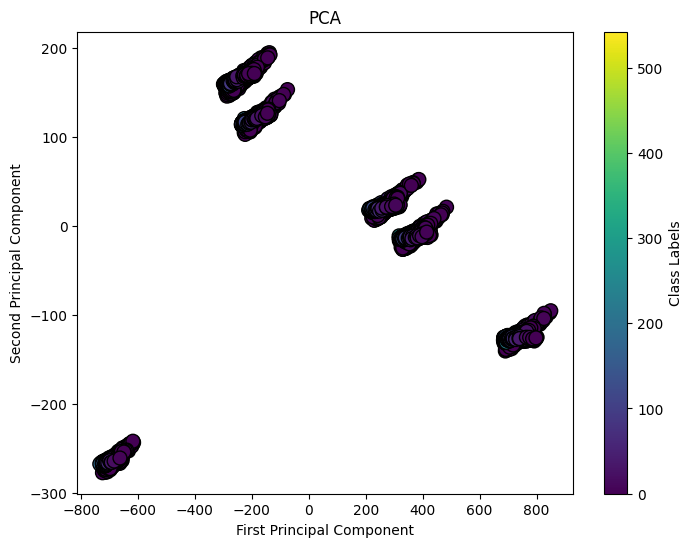

In [231]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=target, cmap='viridis', edgecolor='k', s=100)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA')
plt.colorbar(label='Class Labels')
plt.show()

In [232]:
#Standardize the data for PCA
scaler = StandardScaler()
features = scaler.fit_transform(features)

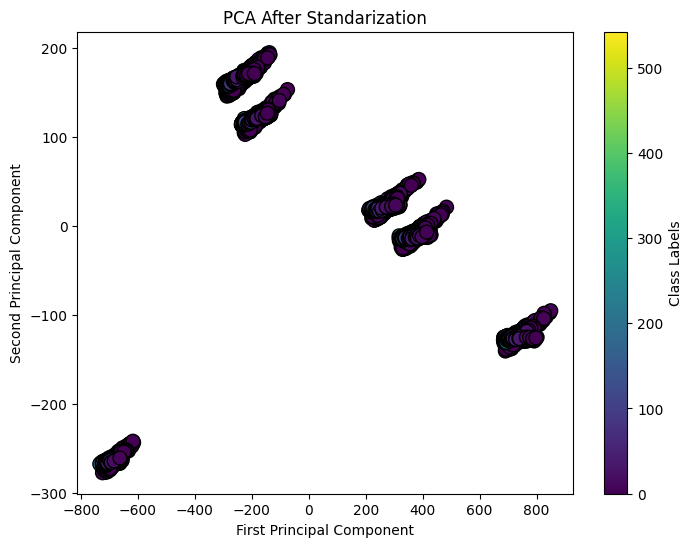

In [233]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=target, cmap='viridis', edgecolor='k', s=100)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA After Standarization')
plt.colorbar(label='Class Labels')
plt.show()

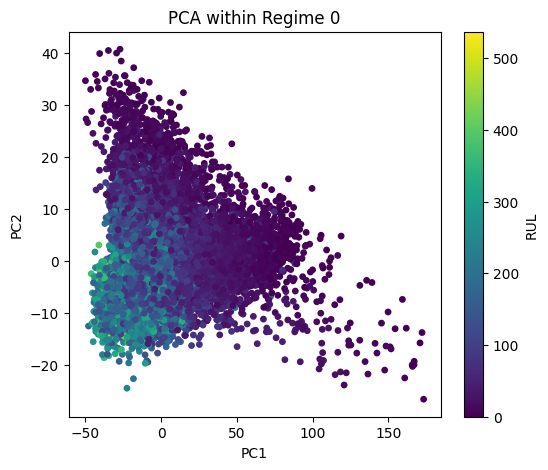

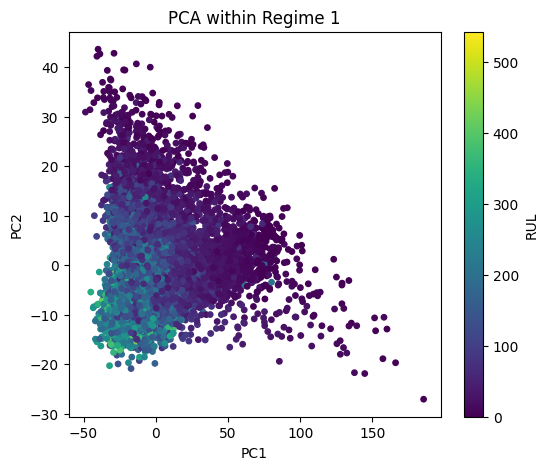

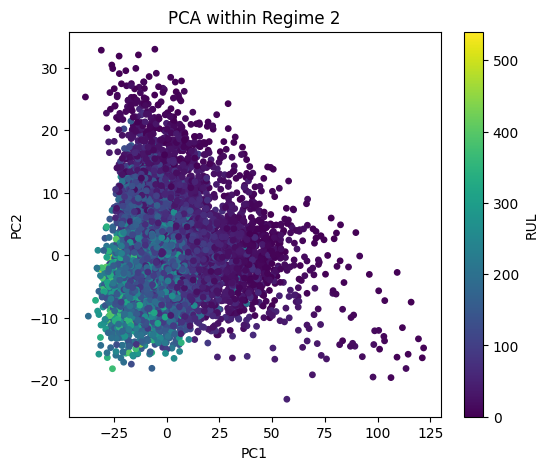

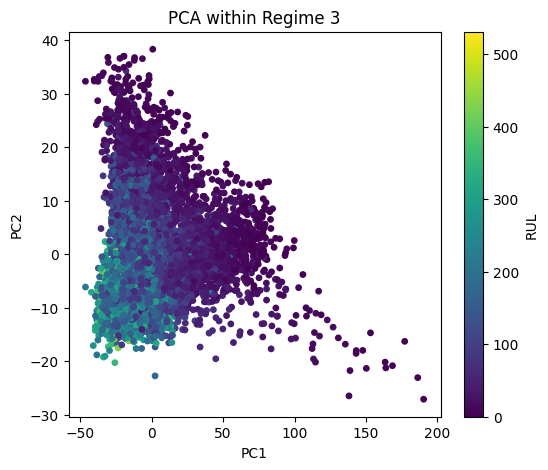

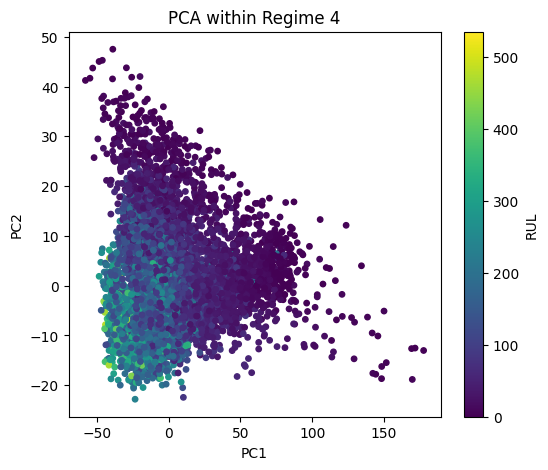

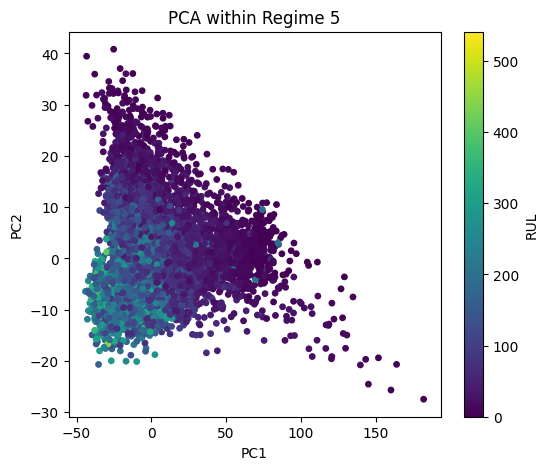

In [234]:
# Select feature columns (exclude identifiers and targets)
feature_cols = [col for col in data.columns
                if col.startswith('sensor_') or col.startswith('op_setting_')]

unique_regimes = sorted(data['regime'].unique())

for r in unique_regimes:

    # Subset regime
    subset = data[data['regime'] == r]

    X = subset[feature_cols].values
    y = subset['RUL'].values  # for coloring

    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # Plot
    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=y,
        cmap='viridis',
        s=15
    )

    plt.colorbar(scatter, label='RUL')
    plt.title(f'PCA within Regime {r}')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.show()


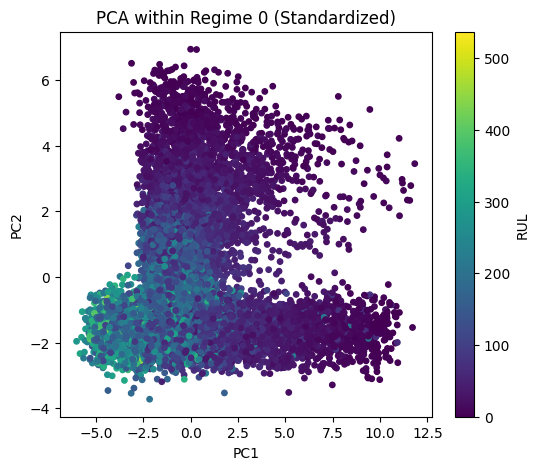

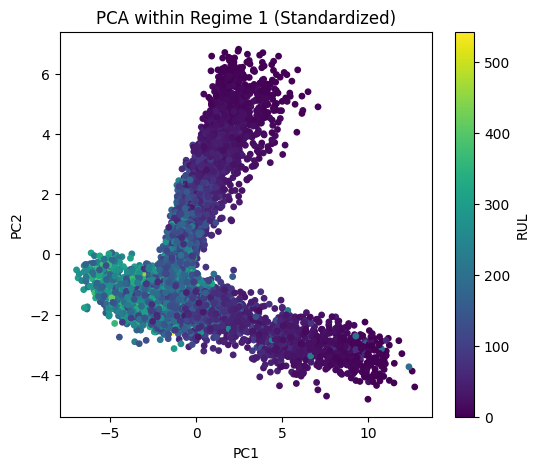

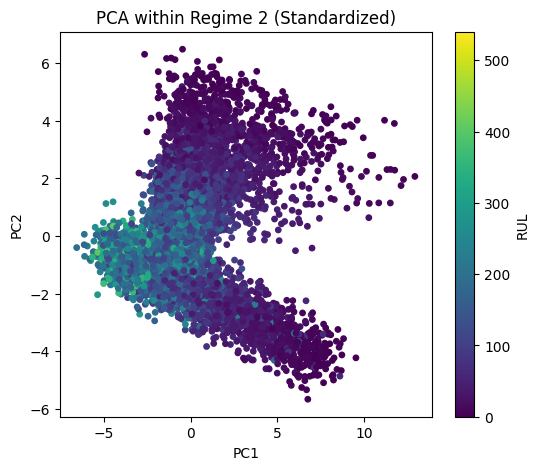

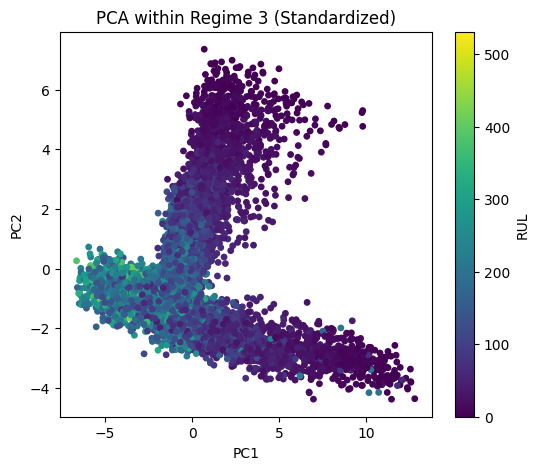

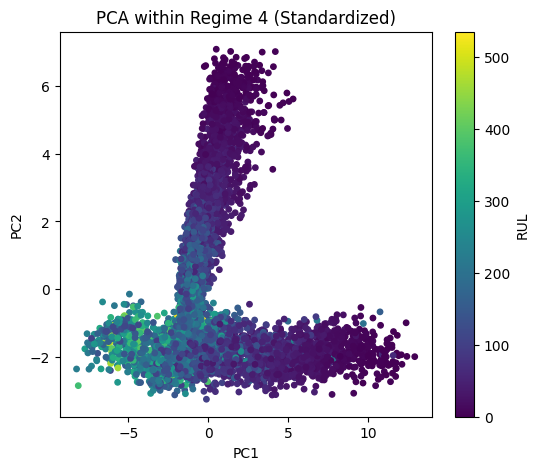

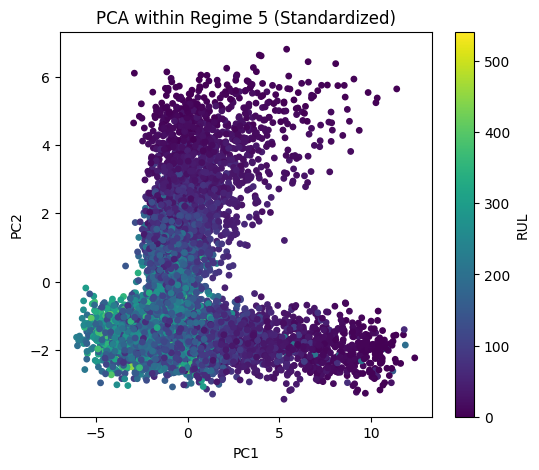

In [237]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Select feature columns
feature_cols = [col for col in data.columns
                if col.startswith('sensor_') or col.startswith('op_setting_')]

unique_regimes = sorted(data['regime'].unique())

for r in unique_regimes:

    # Subset regime
    subset = data[data['regime'] == r]

    X = subset[feature_cols].values
    y = subset['RUL'].values  # for coloring

    # Standardize within this regime
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    # Plot
    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=y,
        cmap='viridis',
        s=15
    )

    plt.colorbar(scatter, label='RUL')
    plt.title(f'PCA within Regime {r} (Standardized)')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.show()

In [238]:
regime_scalers = {}
sensor_cols = [col for col in data.columns if col.startswith('sensor_')]
for regime_id in range(k_optimal):
    mask = data['regime'] == regime_id

    scaler = MinMaxScaler(feature_range=(-1, 1))
    data.loc[mask, sensor_cols] = scaler.fit_transform(
        data.loc[mask, sensor_cols]
    )

    regime_scalers[regime_id] = scaler


for regime_id in range(k_optimal):
    mask = test['regime'] == regime_id

    test.loc[mask, sensor_cols] = regime_scalers[regime_id].transform(
        test.loc[mask, sensor_cols]
    )


/tmp/ipython-input-2645324077.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.27272727 -0.45454545 -0.63636364 ...  0.45454545  0.27272727
  0.27272727]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[mask, sensor_cols] = scaler.fit_transform(
/tmp/ipython-input-2645324077.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.63636364 -0.63636364 -0.63636364 ...  0.09090909  0.09090909
 -0.09090909]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test.loc[mask, sensor_cols] = regime_scalers[regime_id].transform(


In [239]:
train_regime_dummies = pd.get_dummies(data['regime'], prefix='regime').astype(int)
test_regime_dummies = pd.get_dummies(test['regime'], prefix='regime').astype(int)

data = pd.concat([data, train_regime_dummies], axis=1)
test = pd.concat([test, test_regime_dummies], axis=1)

data.drop('regime', axis=1, inplace=True)
test.drop('regime', axis=1, inplace=True)

In [240]:
data

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_20,sensor_21,RUL,regime_0,regime_1,regime_2,regime_3,regime_4,regime_5
0,1,1,0.999852,0.995249,1.0,0.000000,-0.489413,-0.442268,0.200000,-0.694872,-0.433447,-0.717953,-1.000000,-0.476190,-0.587658,-0.384127,-0.648130,0.205276,-1.0,-0.272727,-0.080000,-0.053724,320,1,0,0,0,0,0
1,1,2,-0.047705,0.663183,1.0,-0.773134,-0.329766,-0.564811,-0.090909,-0.687422,-0.770701,-0.733305,-1.000000,-0.516129,-0.771821,-0.880795,-0.768941,0.155291,-1.0,-0.818182,-0.404580,-0.239207,319,0,0,0,1,0,0
2,1,3,0.999800,0.997387,1.0,-0.424419,-0.501916,-0.300687,-0.200000,-0.484615,-0.392491,-0.772984,-1.000000,-0.511905,-0.632539,-0.396825,-0.749139,0.482275,-1.0,-0.454545,-0.360000,0.128033,318,1,0,0,0,0,0
3,1,4,0.999619,0.995249,1.0,-0.569767,-0.577737,-0.267010,0.200000,-0.535897,-0.419795,-0.705711,-0.600000,-0.488095,-0.582048,-0.365079,-0.633120,0.219291,-1.0,-0.636364,-0.240000,0.115649,317,1,0,0,0,0,0
4,1,5,0.190549,0.474347,-1.0,-0.558719,-0.358693,-0.636904,-0.200000,-0.524568,-0.590164,-0.826282,-1.000000,-0.432258,-0.539359,-0.601563,-0.657338,0.014375,-1.0,-0.333333,-0.555556,0.251365,316,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61244,249,251,-0.523910,-0.406176,1.0,0.228650,0.627704,0.144505,-0.333333,0.737360,0.915966,0.062225,0.333333,0.731707,0.674157,0.639344,0.085756,-0.763103,1.0,0.454545,0.661765,0.672540,4,0,1,0,0,0,0
61245,249,252,-0.999867,-0.996437,1.0,0.447514,0.380963,0.546412,-0.142857,0.699065,0.797619,0.109061,0.333333,0.619048,0.746276,0.839506,0.090485,-0.766423,-1.0,0.500000,0.392857,0.636577,3,0,0,0,0,1,0
61246,249,253,-0.999862,-1.000000,1.0,0.591160,0.767861,0.669205,-0.142857,0.834579,0.845238,0.214266,0.333333,0.857143,0.786338,0.864198,0.191861,-0.613390,-1.0,0.333333,0.869048,0.875654,2,0,0,0,0,1,0
61247,249,254,0.666568,0.995249,1.0,-0.005814,0.698460,0.703305,-0.666667,0.694812,0.003413,-0.015444,0.600000,0.693252,0.614537,-0.060703,0.121001,-0.857080,-1.0,0.454545,0.696970,0.389582,1,0,0,0,0,0,1


In [243]:
features = data.drop(['unit_number', 'time_cycles', 'RUL'], axis=1)
target = data['RUL']

In [244]:
pca = PCA(n_components=2)  # Reduce to 2 dimensions for visualization
X_pca = pca.fit_transform(features)

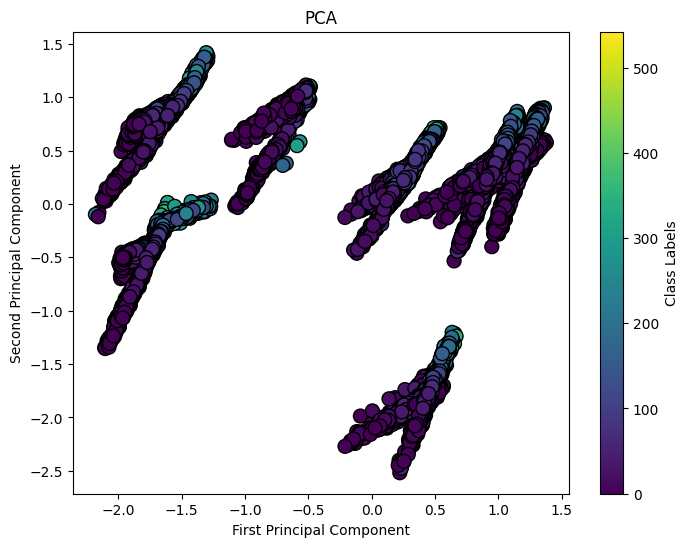

In [245]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=target, cmap='viridis', edgecolor='k', s=100)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA')
plt.colorbar(label='Class Labels')
plt.show()

In [246]:
#Standardize the data for PCA
scaler = StandardScaler()
features = scaler.fit_transform(features)

In [247]:
pca = PCA(n_components=2)  # Reduce to 2 dimensions for visualization
X_pca = pca.fit_transform(features)

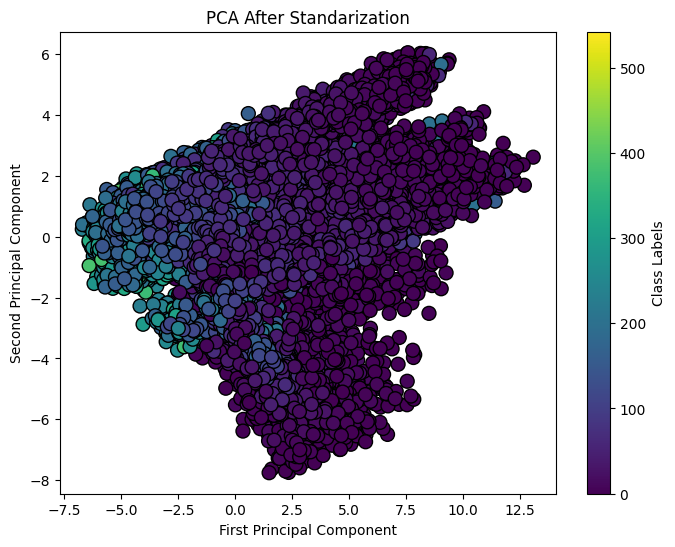

In [248]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=target, cmap='viridis', edgecolor='k', s=100)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA After Standarization')
plt.colorbar(label='Class Labels')
plt.show()